In [1]:
import numpy as np
import pandas as pd
import statistics
import seaborn as sns
import os
import subprocess
import shutil
import plotly.express as px
import sys
sys.path.append('/gpfs/commons/home/mgarbulowski/homic_package/src') 
from homic import file_readers, kraken2, process_data, make_plots
from collections import Counter
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib as mpl

homic package imported


In [2]:
## ## ## ## ## ## ## ## ## ## ## ## ## 
## ## ## ## ILLUMINA ## ## ## ## ## ## 
## ## ## ## ## ## ## ## ## ## ## ## ##

figs_path = "/gpfs/commons/home/mgarbulowski/016_proj_shm/data_polyA_comparison/illumina_data/figs"

path1 = "/gpfs/commons/home/mgarbulowski/016_proj_shm/data_polyA_comparison/illumina_data/Lib9_krk.csv" # lib9 is control
path2 = "/gpfs/commons/home/mgarbulowski/016_proj_shm/data_polyA_comparison/illumina_data/Lib15_krk.csv"
path3 = "/gpfs/commons/home/mgarbulowski/016_proj_shm/data_polyA_comparison/illumina_data/Lib15sub_rep1_krk.csv"
path4 = "/gpfs/commons/home/mgarbulowski/016_proj_shm/data_polyA_comparison/illumina_data/Lib15sub_rep2_krk.csv"

out1 = kraken2.taxid_to_taxainfo(path1)
out2 = kraken2.taxid_to_taxainfo(path2)
out3 = kraken2.taxid_to_taxainfo(path3)
out4 = kraken2.taxid_to_taxainfo(path4)


In [3]:
def papi_clean_species(out):
    specs = out[out["species"] != "unassigned"]
    specs = specs[specs["species"] != "Homo sapiens"]
    specs = specs["species"]

    gens = out[out["genus"] != "unassigned"]
    gens = gens[gens["genus"] != "Homo"]
    gens = gens["genus"]
    
    bacs = out[out["superkingdom"] == "Bacteria"]
    bacs = bacs["superkingdom"]
    
    return specs, gens, bacs

def select_nperc_taxa(tlst, nperc, ntotal):
    counts = Counter(tlst)
    # Convert to DataFrame
    df = pd.DataFrame(counts.items(), columns=['Category', 'Count'])

    # Calculate percentage
    total = df['Count'].sum()
    df['Percentage'] = df['Count'] / ntotal * 100

    # Filter rows where percentage is greater than, e.g., 30%
    filtered_df = df[df['Percentage'] > nperc]

    return filtered_df

specs_1, gens_1, bac_1 = papi_clean_species(out1)
specs_2, gens_2, bac_2 = papi_clean_species(out2)
specs_3, gens_3, bac_3 = papi_clean_species(out3)
specs_4, gens_4, bac_4 = papi_clean_species(out4)



0     0.044882
1     0.033662
2     0.309859
3     0.002589
4     0.180392
5     0.044019
6     0.044882
7     0.011221
8     0.043156
9     0.113932
10    0.118247
11    0.052650
12    0.028483
13    0.030209
14    0.017262
15    0.030209
16    0.005179
17    0.000863
18    0.000863
19    0.004316
20    0.000863
21    0.009494
22    0.000863
23    0.005179
24    0.001726
25    0.000863
26    0.004316
Name: Percentage, dtype: float64
0     1.355095
1     5.089807
2     0.104437
3     0.497156
4     0.106164
5     0.201107
6     0.202833
7     0.047471
8     0.215780
9     0.015536
10    0.036251
11    0.017262
12    0.070776
13    0.028483
14    0.006042
15    0.018989
16    0.002589
17    0.003452
18    0.005179
19    0.003452
20    0.003452
21    0.000863
22    0.008631
23    0.003452
24    0.001726
25    0.004316
26    0.003452
27    0.003452
28    0.005179
29    0.006042
30    0.000863
31    0.001726
32    0.000863
Name: Percentage, dtype: float64
0     0.184707
1     0.484209
2   

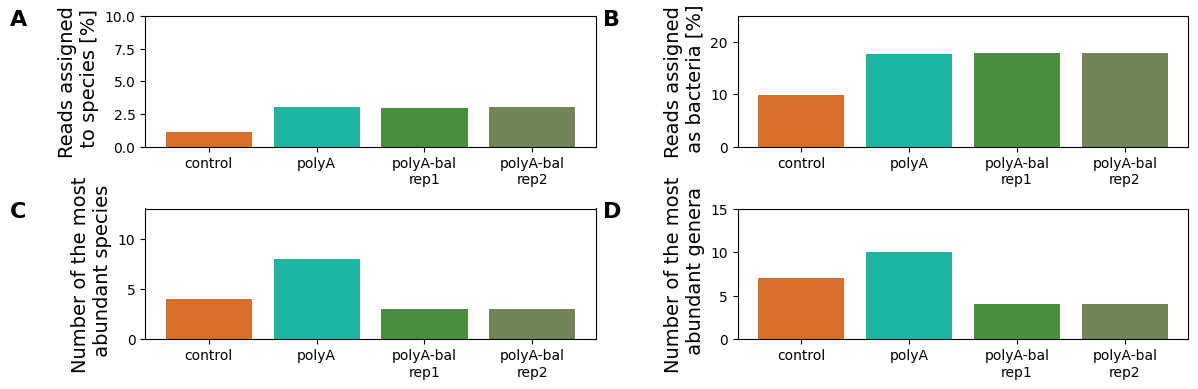

In [4]:
# Sample data
categories = ['control','polyA','polyA-bal\nrep1','polyA-bal\nrep2']

krk_out1 =  pd.read_csv(path1)
krk_out2 =  pd.read_csv(path2)
krk_out3 =  pd.read_csv(path3)
krk_out4 =  pd.read_csv(path4)

# species
prc_ctrl1 = len(specs_1)/krk_out1.shape[0]*100
prc_polyA1 = len(specs_2)/krk_out2.shape[0]*100
prc_polyAbr11 = len(specs_3)/krk_out3.shape[0]*100
prc_polyAbr21 = len(specs_4)/krk_out4.shape[0]*100

# bacteria
prc_ctrl2 = len(bac_1)/krk_out1.shape[0]*100
prc_polyA2 = len(bac_2)/krk_out2.shape[0]*100
prc_polyAbr12 = len(bac_3)/krk_out3.shape[0]*100
prc_polyAbr22 = len(bac_4)/krk_out4.shape[0]*100

values1 = [prc_ctrl1, prc_polyA1, prc_polyAbr11, prc_polyAbr21]
values2 = [prc_ctrl2, prc_polyA2, prc_polyAbr12, prc_polyAbr22]

perc_thr = 0.1

specs_1_ab = list(select_nperc_taxa(specs_1, perc_thr, krk_out1.shape[0])["Category"])
specs_2_ab = list(select_nperc_taxa(specs_2, perc_thr, krk_out1.shape[0])["Category"])
specs_3_ab = list(select_nperc_taxa(specs_3, perc_thr, krk_out1.shape[0])["Category"])
specs_4_ab = list(select_nperc_taxa(specs_4, perc_thr, krk_out1.shape[0])["Category"])

gens_1_ab = list(select_nperc_taxa(gens_1, perc_thr, krk_out1.shape[0])["Category"])
gens_2_ab = list(select_nperc_taxa(gens_2, perc_thr, krk_out1.shape[0])["Category"])
gens_3_ab = list(select_nperc_taxa(gens_3, perc_thr, krk_out1.shape[0])["Category"])
gens_4_ab = list(select_nperc_taxa(gens_4, perc_thr, krk_out1.shape[0])["Category"])


values3 = [len(set(specs_1_ab)), len(set(specs_2_ab)), len(set(specs_3_ab)), len(set(specs_4_ab))]
values4 = [len(set(gens_1_ab)), len(set(gens_2_ab)), len(set(gens_3_ab)), len(set(gens_4_ab))]

# Create figure and subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 4))
axes = axes.flatten()  # Flatten 2x2 array into a 1D list

# List of data and labels
datasets = [(values1, 'A'), (values2, 'B'), (values3, 'C'), (values4, 'D')]
ylim_vals = [(0,10),(0,25),(0,max(values3)+5),(0,max(values4)+5)]
y_labels = ['Reads assigned\n to species [%]',
            'Reads assigned\n as bacteria [%]',
            'Number of the most\n abundant species',
            'Number of the most\n abundant genera']

for ax, (values, label), y_label, yvals in zip(axes, datasets, y_labels, ylim_vals):
    ax.bar(categories, values, color=['#D96E2B', '#1BB5A1', '#488F40', '#718556'])
    ax.set_ylim(yvals)
    ax.set_ylabel(y_label, fontsize=14)
    ax.text(-0.3, 1.05, label, transform=ax.transAxes,
            fontsize=16, fontweight='bold', va='top', ha='left')

plt.tight_layout()
plt.show()
fig.set_size_inches(8, 5)
fig.savefig(figs_path + "/polyA_vs_ctrl_illumina.png", dpi=300, bbox_inches='tight')

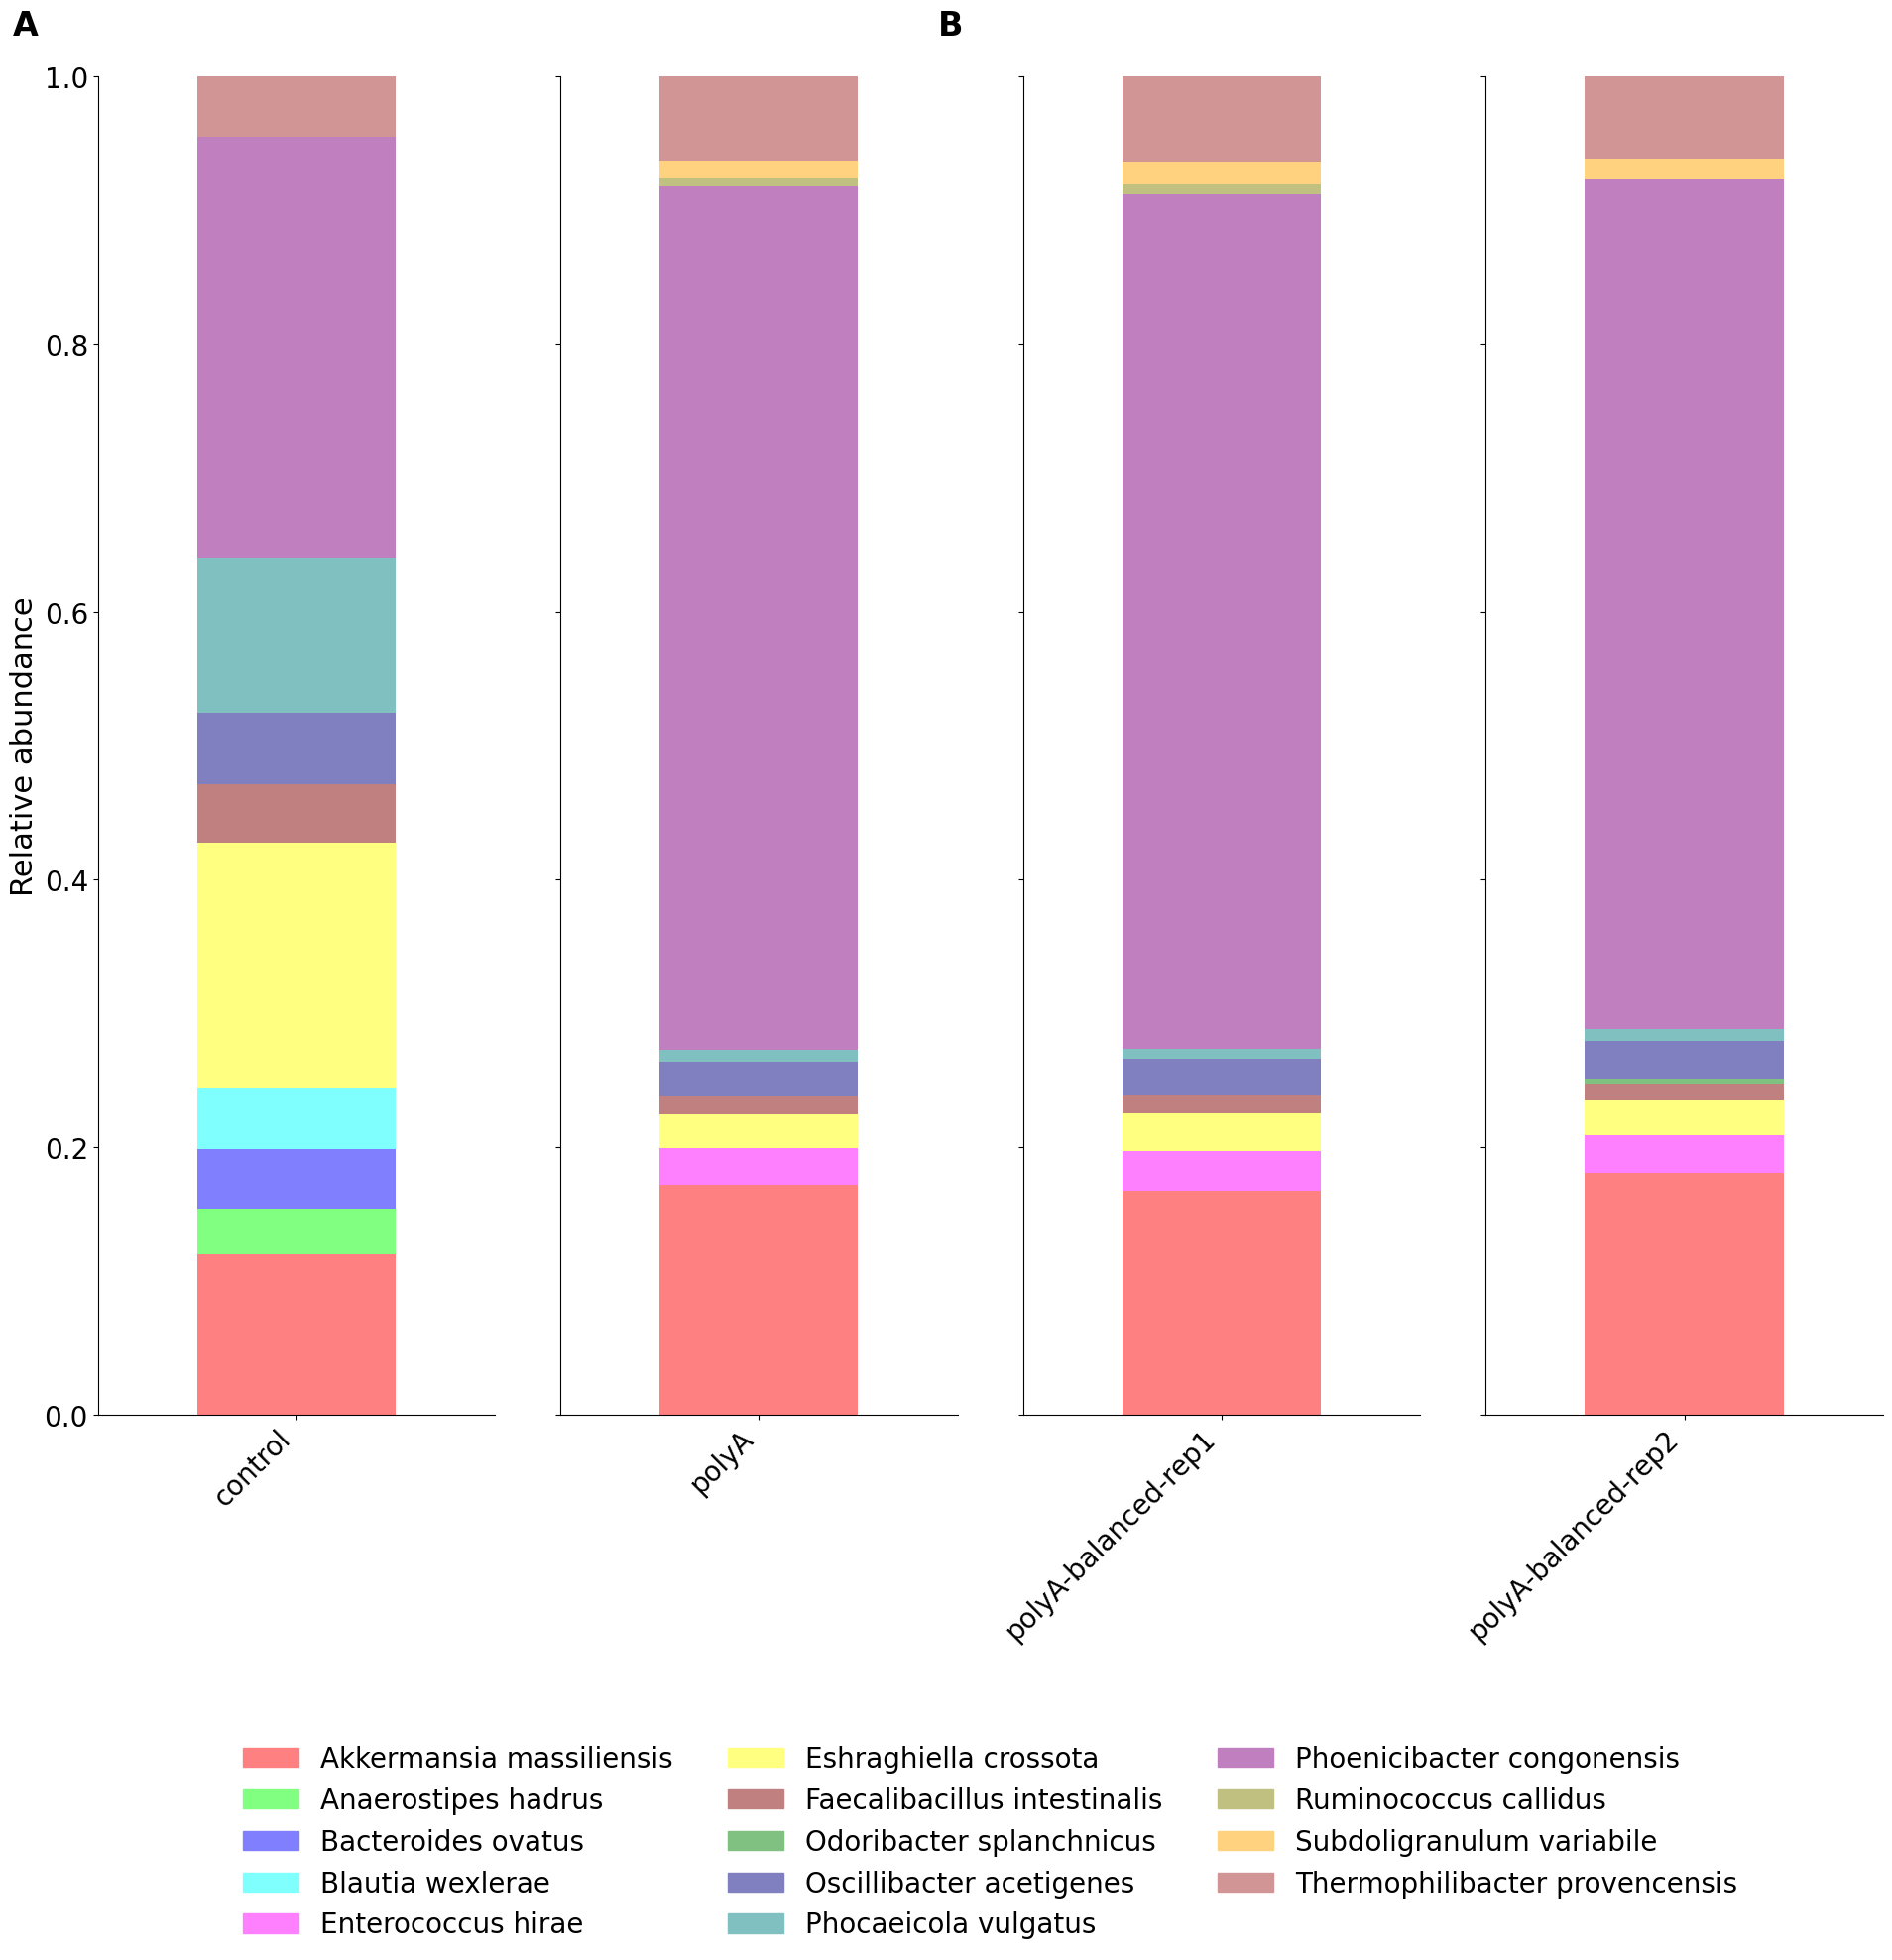

In [5]:
def baclist_to_bacdf(taxa_list, ntop):

    c01 = Counter(taxa_list)
    c01 = c01.most_common(ntop)
    fe, se = zip(*c01)
    vals = list(se)
    inds = list(fe)

    df = pd.DataFrame({'abundance': vals},
                  index=inds)
    df = df.groupby(df.index).sum()
    df = df.div(df.sum(axis=0), axis=1)
    return df
    
ntop = 10
df1 = baclist_to_bacdf(specs_1, ntop)
df2 = baclist_to_bacdf(specs_2, ntop)
df3 = baclist_to_bacdf(specs_3, ntop)
df4 = baclist_to_bacdf(specs_4, ntop)

data_list = [df1, df2, df3, df4]
bar_subtitles = ["control","polyA","polyA-balanced-rep1","polyA-balanced-rep2"]
fig = make_plots.relative_abundance_four(data_list, bar_subtitles, common_legend=True, clegend_nrows=6)
fig.savefig(figs_path + "/relative_abundance_species_illumina.png", dpi=300, bbox_inches='tight')

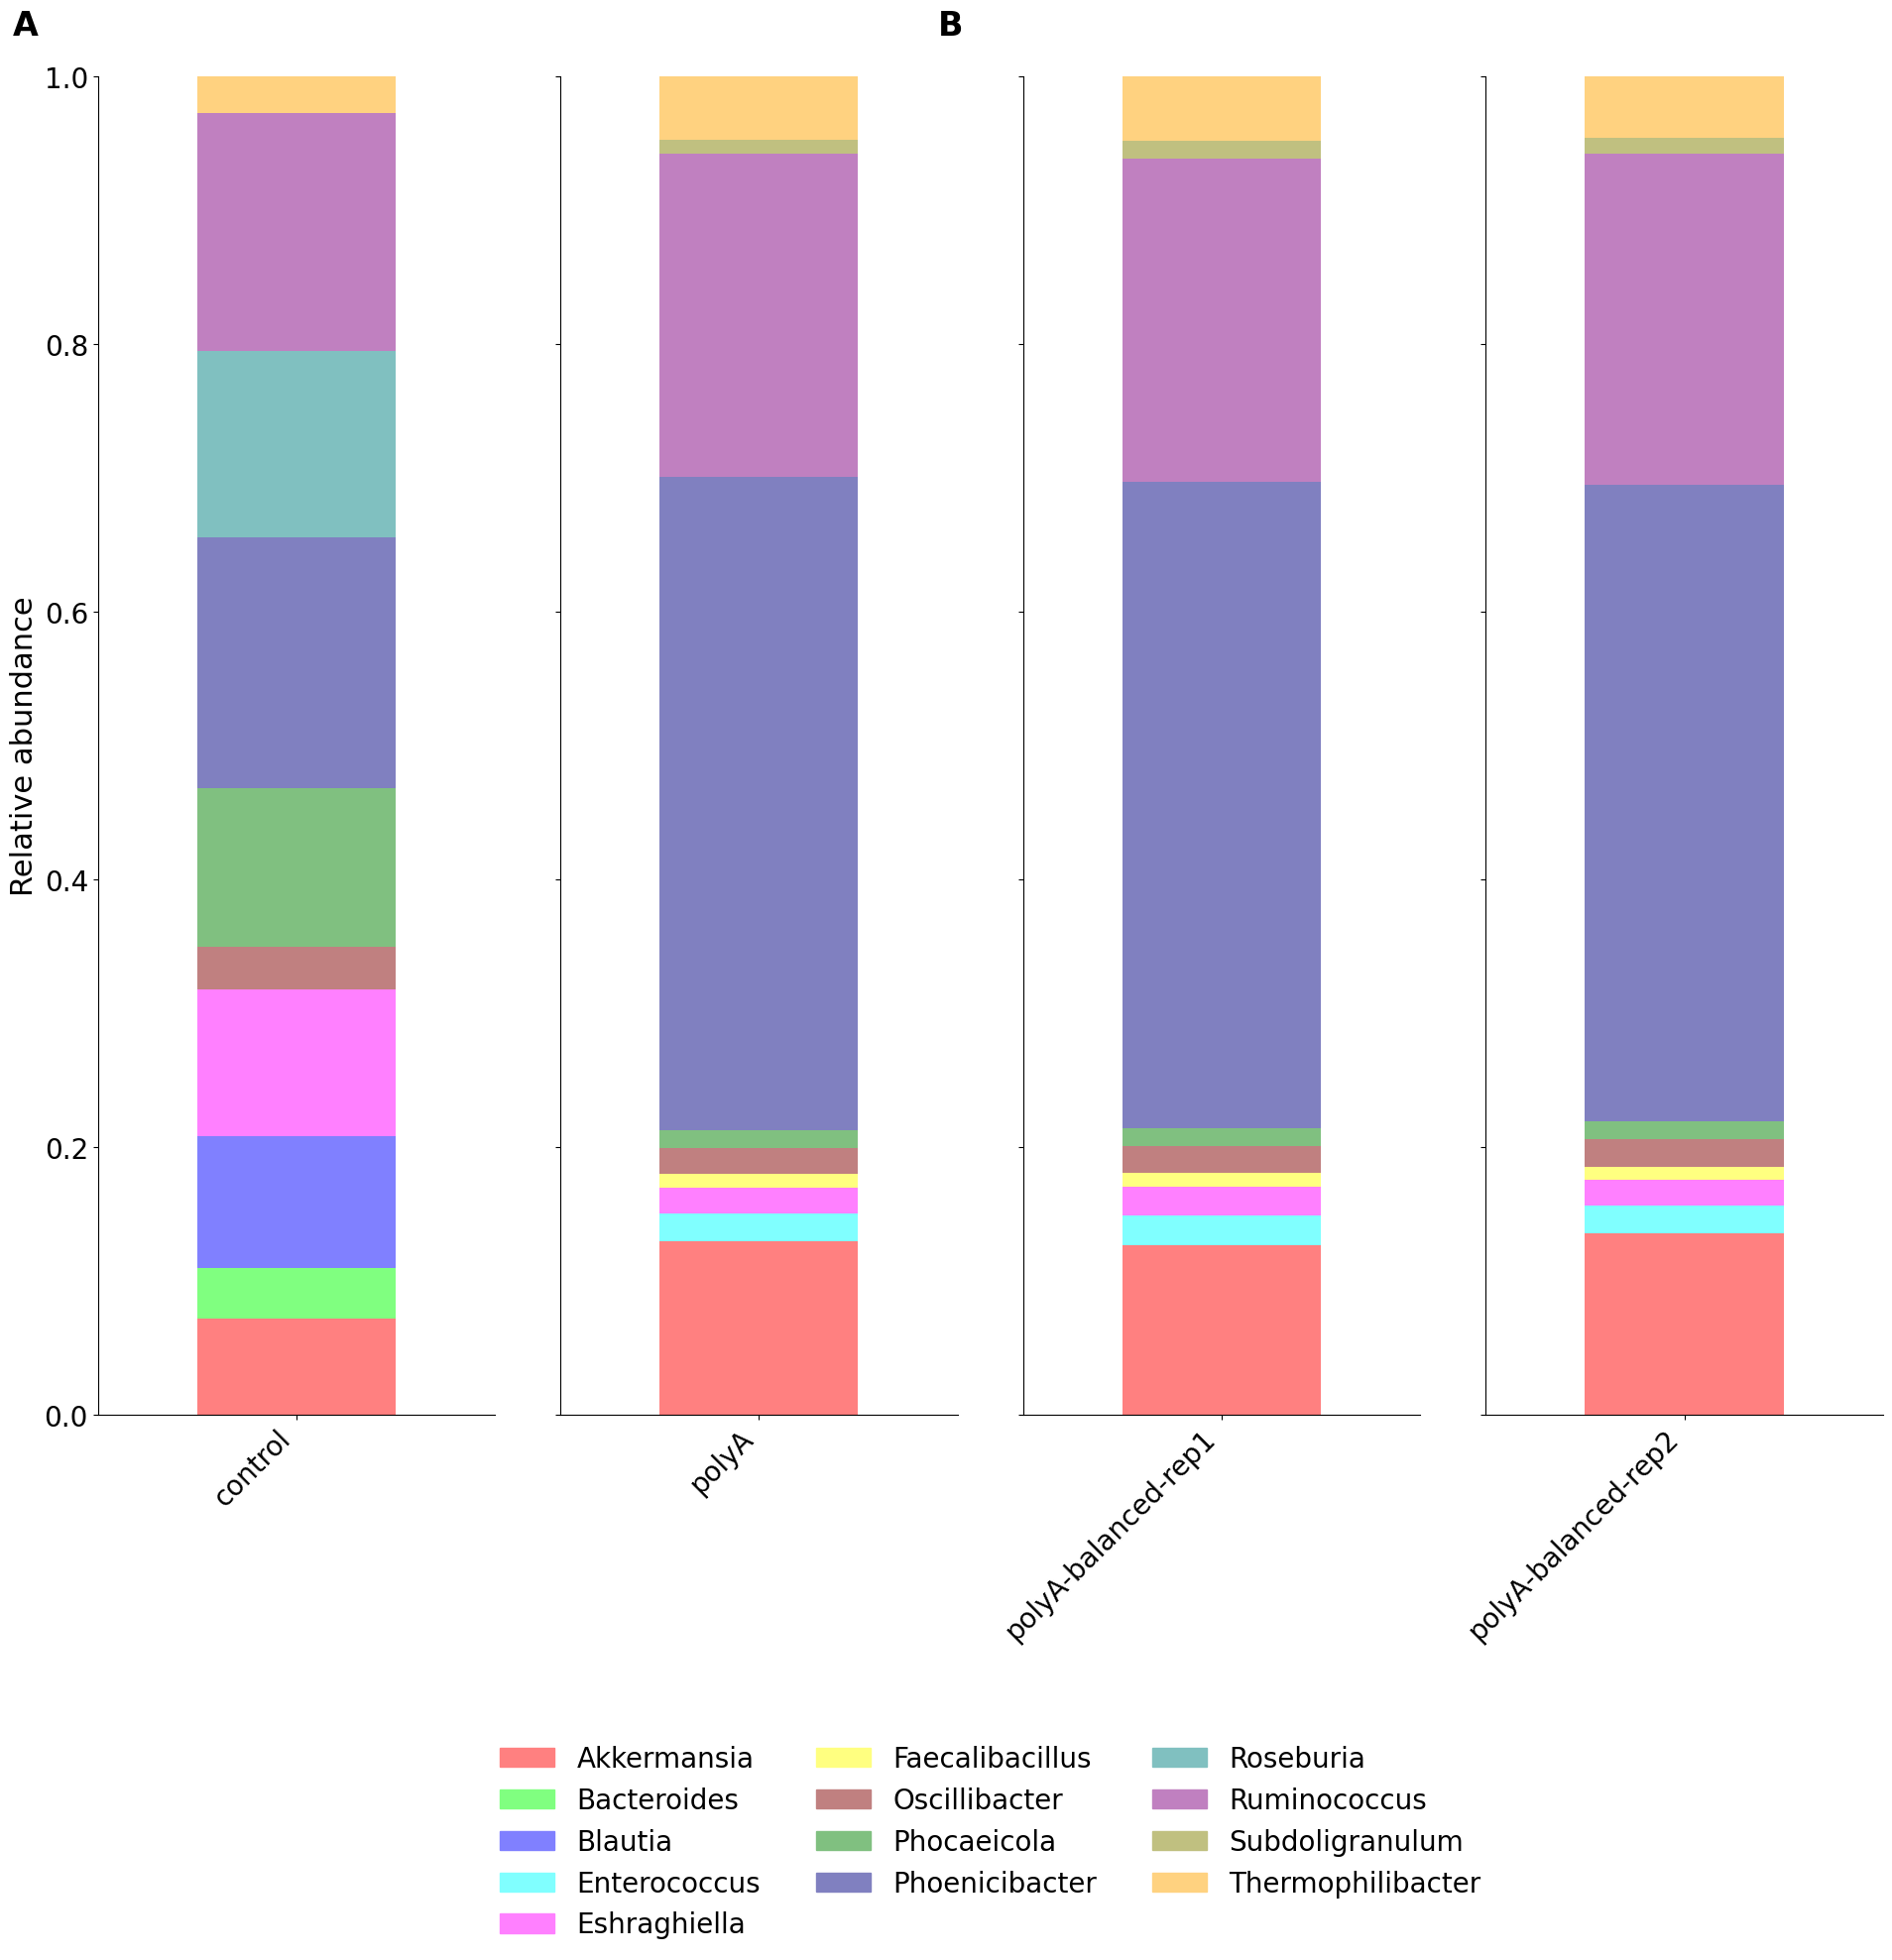

In [6]:
ntop = 10
df1 = baclist_to_bacdf(gens_1, ntop)
df2 = baclist_to_bacdf(gens_2, ntop)
df3 = baclist_to_bacdf(gens_3, ntop)
df4 = baclist_to_bacdf(gens_4, ntop)

data_list = [df1, df2, df3, df4]
bar_subtitles = ["control","polyA","polyA-balanced-rep1","polyA-balanced-rep2"]
fig = make_plots.relative_abundance_four(data_list, bar_subtitles, common_legend=True, clegend_nrows=6)
fig.savefig(figs_path + "/relative_abundance_genera_illumina.png", dpi=300, bbox_inches='tight')

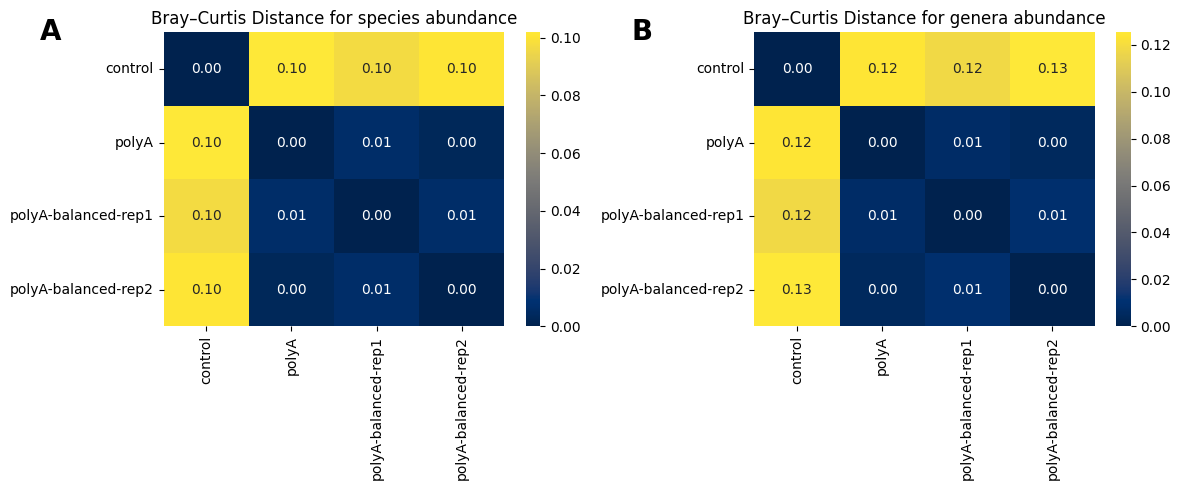

In [7]:
from scipy.spatial.distance import pdist, squareform
import seaborn as sns
import matplotlib.pyplot as plt

listed_data = [out1, out2, out3, out4]
counts = [Counter(df["species"]) for df in listed_data]
data_names = bar_subtitles

# create DataFrame from all counts
df = pd.DataFrame(counts).fillna(0).astype(int)
df = df.T
df.columns = data_names


df[bar_subtitles[0]] = (df[bar_subtitles[0]]/df[bar_subtitles[0]].sum()) 
df[bar_subtitles[1]] = (df[bar_subtitles[1]]/df[bar_subtitles[1]].sum()) 
df[bar_subtitles[2]] = (df[bar_subtitles[2]]/df[bar_subtitles[2]].sum()) 
df[bar_subtitles[3]] = (df[bar_subtitles[3]]/df[bar_subtitles[3]].sum()) 
df = df.T

# Compute pairwise bray-curtis distances
bray = pdist(df, metric="braycurtis")

# Convert to a square matrix
bray_matrix = pd.DataFrame(
    squareform(bray), 
    index=df.index, 
    columns=df.index
)

## genus
countsg = [Counter(df["genus"]) for df in listed_data]

# create DataFrame from all counts
dfg = pd.DataFrame(countsg).fillna(0).astype(int)
dfg = dfg.T
dfg.columns = data_names


dfg[bar_subtitles[0]] = (dfg[bar_subtitles[0]]/dfg[bar_subtitles[0]].sum()) 
dfg[bar_subtitles[1]] = (dfg[bar_subtitles[1]]/dfg[bar_subtitles[1]].sum()) 
dfg[bar_subtitles[2]] = (dfg[bar_subtitles[2]]/dfg[bar_subtitles[2]].sum()) 
dfg[bar_subtitles[3]] = (dfg[bar_subtitles[3]]/dfg[bar_subtitles[3]].sum()) 
dfg = dfg.T
bray_genus = pdist(dfg, metric="braycurtis")

# Convert to a square matrix
bray_matrix_genus = pd.DataFrame(
    squareform(bray_genus), 
    index=dfg.index, 
    columns=dfg.index
)

# Optional: create labels for rows/columns
labels = ['A', 'B', 'C', 'D', 'E']

# Create subplots: 1 row, 2 columns
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot first heatmap
sns.heatmap(bray_matrix, ax=axes[0], annot=True, fmt=".2f", cmap="cividis")
axes[0].set_title("Bray–Curtis Distance for species abundance")
axes[0].text(-0.3, 1.05, 'A', transform=axes[0].transAxes, 
             fontsize=20, fontweight='bold', va='top', ha='right')

# Plot second heatmap
sns.heatmap(bray_matrix_genus, ax=axes[1], annot=True, fmt=".2f", cmap="cividis")
axes[1].set_title("Bray–Curtis Distance for genera abundance")
axes[1].text(-0.3, 1.05, 'B', transform=axes[1].transAxes, 
             fontsize=20, fontweight='bold', va='top', ha='right')

plt.tight_layout()
plt.show()


fig.savefig(figs_path + "/bray_curtis_heatmap_of_abundances.png", dpi=300, bbox_inches="tight")  # PNG format

In [8]:
path1 = "/gpfs/commons/home/mgarbulowski/016_proj_shm/data_polyA_comparison/illumina_data/Lib9_krk_nod.csv"
path2 = "/gpfs/commons/home/mgarbulowski/016_proj_shm/data_polyA_comparison/illumina_data/Lib15_krk_nod.csv"

out1 = kraken2.taxid_to_taxainfo(path1)
out2 = kraken2.taxid_to_taxainfo(path2)

In [9]:
hs_ctrl1 = sum(out1["species"] == "Homo sapiens")
hs_polya1 = sum(out2["species"] == "Homo sapiens")

bac_ctrl1 = sum(out1["superkingdom"] == "Bacteria")
bac_polya1 = sum(out2["superkingdom"] == "Bacteria")

others_ctrl1 = out1.shape[0] - hs_ctrl1 - bac_ctrl1
others_polya1 = out2.shape[0] - hs_polya1 - bac_polya1


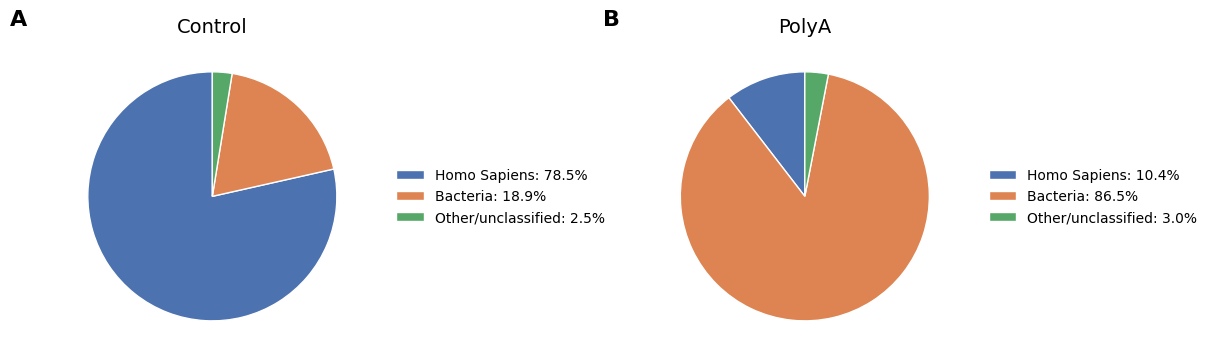

In [10]:

figs_path = "/gpfs/commons/home/mgarbulowski/016_proj_shm/data_polyA_comparison/illumina_data/figs"
# Data
values_A = [hs_ctrl1, bac_ctrl1, others_ctrl1]
values_B = [hs_polya1, bac_polya1, others_polya1]
labels = ['Homo Sapiens', 'Bacteria', 'Other/unclassified']
# Scientific, elegant color palette
colors = ["#4C72B0", "#DD8452", "#55A868"]

# Percent labels for legends
pct_A = [f"{l}: {v/sum(values_A)*100:.1f}%" for l, v in zip(labels, values_A)]
pct_B = [f"{l}: {v/sum(values_B)*100:.1f}%" for l, v in zip(labels, values_B)]

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ==== FIGURE A ====
axes[0].pie(
    values_A,
    startangle=90,
    colors=colors,
    wedgeprops={'linewidth': 1, 'edgecolor': 'white'}
)
axes[0].set_title("Control", fontsize=14)
axes[0].text(-0.15, 1.05, "A", fontsize=16, fontweight='bold', transform=axes[0].transAxes)

# Legend outside
axes[0].legend(
    pct_A,
    title="",
    loc="center left",
    bbox_to_anchor=(1.05, 0.5),
    frameon=False
)

# ==== FIGURE B ====
axes[1].pie(
    values_B,
    startangle=90,
    colors=colors,
    wedgeprops={'linewidth': 1, 'edgecolor': 'white'}
)
axes[1].set_title("PolyA", fontsize=14)
axes[1].text(-0.15, 1.05, "B", fontsize=16, fontweight='bold', transform=axes[1].transAxes)

# Legend outside
axes[1].legend(
    pct_B,
    title="",
    loc="center left",
    bbox_to_anchor=(1.05, 0.5),
    frameon=False
)

plt.tight_layout()
plt.show()

fig.savefig(figs_path + "/kraken_without_hostdecontamination.png", dpi=300, bbox_inches="tight")  # PNG format

In [11]:
path1 = "/gpfs/commons/home/mgarbulowski/016_proj_shm/data_polyA_comparison/illumina_data/Lib9_krk_nod_nof.csv"
path2 = "/gpfs/commons/home/mgarbulowski/016_proj_shm/data_polyA_comparison/illumina_data/Lib15_krk_nod_nof.csv"

out1 = kraken2.taxid_to_taxainfo(path1)
out2 = kraken2.taxid_to_taxainfo(path2)

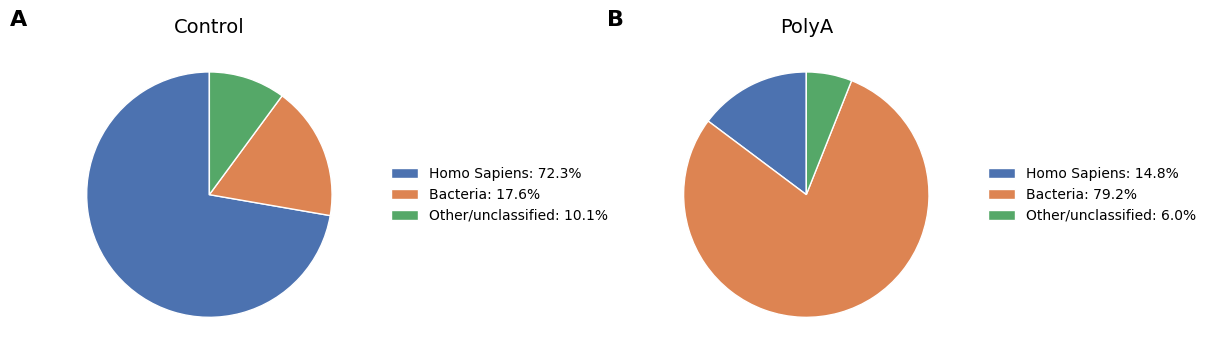

In [12]:
hs_ctrl2 = sum(out1["species"] == "Homo sapiens")
hs_polya2 = sum(out2["species"] == "Homo sapiens")

bac_ctrl2 = sum(out1["superkingdom"] == "Bacteria")
bac_polya2 = sum(out2["superkingdom"] == "Bacteria")

others_ctrl2 = out1.shape[0] - hs_ctrl2 - bac_ctrl2
others_polya2 = out2.shape[0] - hs_polya2 - bac_polya2

# Data
values_A = [hs_ctrl2, bac_ctrl2, others_ctrl2]
values_B = [hs_polya2, bac_polya2, others_polya2]
labels = ['Homo Sapiens', 'Bacteria', 'Other/unclassified']
# Scientific, elegant color palette
colors = ["#4C72B0", "#DD8452", "#55A868"]

# Percent labels for legends
pct_A = [f"{l}: {v/sum(values_A)*100:.1f}%" for l, v in zip(labels, values_A)]
pct_B = [f"{l}: {v/sum(values_B)*100:.1f}%" for l, v in zip(labels, values_B)]

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ==== FIGURE A ====
axes[0].pie(
    values_A,
    startangle=90,
    colors=colors,
    wedgeprops={'linewidth': 1, 'edgecolor': 'white'}
)
axes[0].set_title("Control", fontsize=14)
axes[0].text(-0.15, 1.05, "A", fontsize=16, fontweight='bold', transform=axes[0].transAxes)

# Legend outside
axes[0].legend(
    pct_A,
    title="",
    loc="center left",
    bbox_to_anchor=(1.05, 0.5),
    frameon=False
)

# ==== FIGURE B ====
axes[1].pie(
    values_B,
    startangle=90,
    colors=colors,
    wedgeprops={'linewidth': 1, 'edgecolor': 'white'}
)
axes[1].set_title("PolyA", fontsize=14)
axes[1].text(-0.15, 1.05, "B", fontsize=16, fontweight='bold', transform=axes[1].transAxes)

# Legend outside
axes[1].legend(
    pct_B,
    title="",
    loc="center left",
    bbox_to_anchor=(1.05, 0.5),
    frameon=False
)

plt.tight_layout()
plt.show()

fig.savefig(figs_path + "/kraken_without_hostdecontamination_and_qcfiltering.png", dpi=300, bbox_inches="tight")  # PNG format

In [8]:
#path1 = "/gpfs/commons/home/mgarbulowski/016_proj_shm/data_polyA_comparison/illumina_data/results_rs_lib9.txt"
#path2 = "/gpfs/commons/home/mgarbulowski/016_proj_shm/data_polyA_comparison/illumina_data/results_rs_lib15.txt"

path1 = "/gpfs/commons/home/mgarbulowski/016_proj_shm/data_polyA_comparison/illumina_data/results_152m_lib9.txt"
path2 = "/gpfs/commons/home/mgarbulowski/016_proj_shm/data_polyA_comparison/illumina_data/results_152m_lib15.txt"

import pandas as pd
import numpy as np

def annotate_blast_positions(
        blast_file,
        genome_csv,
        strand_filter="both",
        five_prime_threshold=0.1,
        three_prime_threshold=0.9
    ):
    """
    Annotate BLAST positions with optional strand filtering.

    Parameters
    ----------
    blast_file : str
        BLASTN tabular output (-outfmt 6)

    genome_csv : str
        CSV with columns: accession,organism,genome_length_bp

    strand_filter : str
        "both"  -> keep + and -
        "+"     -> keep only plus-strand hits
        "-"     -> keep only minus-strand hits

    five_prime_threshold : float
        relative position threshold for 5' end

    three_prime_threshold : float
        relative position threshold for 3' end

    Returns
    -------
    pandas DataFrame with:
        qseqid, sseqid, start, end, strand, rel_start, rel_end, location, Bfull_length
    """

    # Load BLAST output
    cols = ["qseqid","sseqid","pident","length","mismatch","gapopen",
            "qstart","qend","sstart","send","evalue","bitscore"]
    df = pd.read_csv(blast_file, sep="\t", names=cols)

    # Extract accession from "ref|ACCESSION|"
    df["accession"] = df["sseqid"].str.extract(r'ref\|([^|]+)\|')[0].fillna(df["sseqid"])

    # Load genome lengths
    genome_df = pd.read_csv(genome_csv)
    genome_map = dict(zip(genome_df["accession"], genome_df["genome_length_bp"]))
    df["Bfull_length"] = df["accession"].map(genome_map)

    # Warn about missing lengths
    missing = df[df["Bfull_length"].isna()]["accession"].unique()
    if len(missing) > 0:
        print("WARNING: missing genome lengths for:", missing)

    # Normalize coordinates
    df["start"] = df[["sstart","send"]].min(axis=1)
    df["end"]   = df[["sstart","send"]].max(axis=1)

    # Determine strand relative to reference genome
    df["strand"] = np.where(df["sstart"] < df["send"], "+", "-")

    # Strand filtering
    if strand_filter == "+":
        df = df[df["strand"] == "+"]
    elif strand_filter == "-":
        df = df[df["strand"] == "-"]
    elif strand_filter != "both":
        raise ValueError("strand_filter must be 'both', '+', or '-'")

    # Compute relative genome positions
    df["rel_start"] = df["start"] / df["Bfull_length"]
    df["rel_end"]   = df["end"]   / df["Bfull_length"]

    # 5'/3' assignment (relative to reference!)
    def label_location(row):
        if row["rel_start"] < five_prime_threshold:
            return "close to 5' end"
        elif row["rel_end"] > three_prime_threshold:
            return "close to 3' end"
        return "middle region"

    df["location"] = df.apply(label_location, axis=1)

    return df[[
        "qseqid","sseqid","start","end","strand",
        "rel_start","rel_end","location","Bfull_length"
    ]]


genlens_path = "/gpfs/commons/home/mgarbulowski/016_proj_shm/ref_dbs/blastn/genome_info_150m.csv"

annotated_df1 = annotate_blast_positions(path1, genlens_path, strand_filter="both", five_prime_threshold=0.2, three_prime_threshold=0.8)
annotated_df2 = annotate_blast_positions(path2, genlens_path, strand_filter="both", five_prime_threshold=0.2, three_prime_threshold=0.8)


In [9]:
print(annotated_df1)

print(np.median(annotated_df1["Bfull_length"]))

                                              qseqid  \
0       M00911:314:000000000-DV78T:1:1102:10490:2437   
1       M00911:314:000000000-DV78T:1:1102:13888:2445   
2       M00911:314:000000000-DV78T:1:1102:15864:2446   
3       M00911:314:000000000-DV78T:1:1102:13706:2446   
4       M00911:314:000000000-DV78T:1:1102:15534:2450   
...                                              ...   
20837  M00911:314:000000000-DV78T:1:1101:16461:28242   
20838  M00911:314:000000000-DV78T:1:1101:12471:28247   
20839  M00911:314:000000000-DV78T:1:1101:19405:28274   
20840  M00911:314:000000000-DV78T:1:1101:13126:28284   
20841  M00911:314:000000000-DV78T:1:1101:19207:28288   

                          sseqid    start      end strand  rel_start  \
0             ref|NZ_CP094882.1|  1717170  1717320      +   0.815270   
1      ref|NZ_JAKZMM010000001.1|      955     1108      +   0.446888   
2               ref|NC_021039.1|    66363    66484      +   0.025790   
3             ref|NZ_CP102270.1|    128

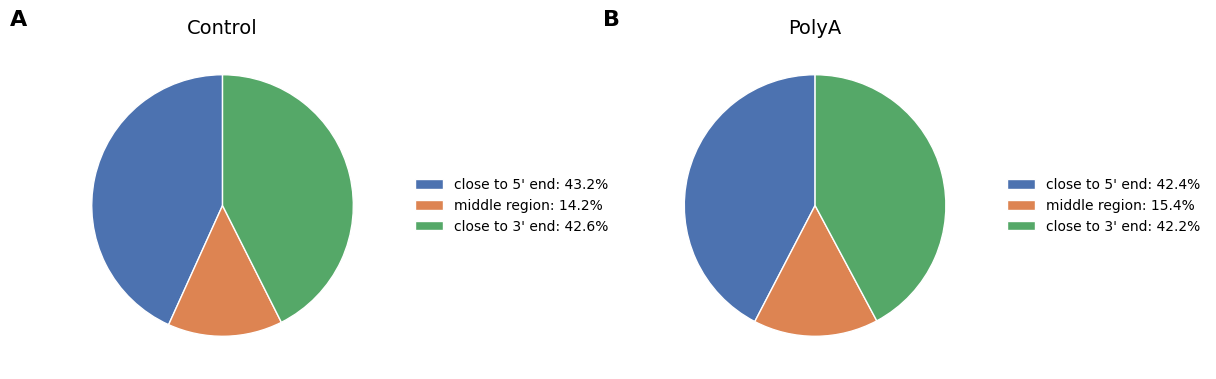

In [10]:

figs_path = "/gpfs/commons/home/mgarbulowski/016_proj_shm/data_polyA_comparison/illumina_data/figs"
# Data
labels = ["close to 5' end", "middle region", "close to 3' end"]

location_counts = annotated_df1['location'].value_counts()
values_A = [location_counts.get(label, 0) for label in labels]
location_counts = annotated_df2['location'].value_counts()
values_B = [location_counts.get(label, 0) for label in labels]


# Scientific, elegant color palette
colors = ["#4C72B0", "#DD8452", "#55A868"]

# Percent labels for legends
pct_A = [f"{l}: {v/sum(values_A)*100:.1f}%" for l, v in zip(labels, values_A)]
pct_B = [f"{l}: {v/sum(values_B)*100:.1f}%" for l, v in zip(labels, values_B)]

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ==== FIGURE A ====
axes[0].pie(
    values_A,
    startangle=90,
    colors=colors,
    wedgeprops={'linewidth': 1, 'edgecolor': 'white'}
)
axes[0].set_title("Control", fontsize=14)
axes[0].text(-0.15, 1.05, "A", fontsize=16, fontweight='bold', transform=axes[0].transAxes)

# Legend outside
axes[0].legend(
    pct_A,
    title="",
    loc="center left",
    bbox_to_anchor=(1.05, 0.5),
    frameon=False
)

# ==== FIGURE B ====
axes[1].pie(
    values_B,
    startangle=90,
    colors=colors,
    wedgeprops={'linewidth': 1, 'edgecolor': 'white'}
)
axes[1].set_title("PolyA", fontsize=14)
axes[1].text(-0.15, 1.05, "B", fontsize=16, fontweight='bold', transform=axes[1].transAxes)

# Legend outside
axes[1].legend(
    pct_B,
    title="",
    loc="center left",
    bbox_to_anchor=(1.05, 0.5),
    frameon=False
)

plt.tight_layout()
plt.show()

fig.savefig(figs_path + "/mapping_place_bacteria_body_illumina_152m.png", dpi=300, bbox_inches="tight") 

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_and_extract_peak_bin(df, out_fnam, bins=50, peak_range_plus=(0.8, 1), peak_range_minus=(0, 0.2)):
    """
    Plot strand-aware histograms, highlight the peak bin, annotate its range,
    and return a subset of df corresponding to the detected maximum bin.
    
    Parameters:
    - df: DataFrame with 'strand', 'start', 'end', 'Bfull_length' columns
    - bins: number of histogram bins
    - peak_range_plus: tuple for + strand peak search range
    - peak_range_minus: tuple for - strand peak search range
    
    Returns:
    - subset_df: DataFrame containing only rows within the detected peak bins
    """
    df = df.copy()

    # Compute unified normalized coordinate (5'→3')
    df.loc[df["strand"] == "+", "norm_pos"] = df["start"] / df["Bfull_length"]
    df.loc[df["strand"] == "-", "norm_pos"] = 1 - (df["end"] / df["Bfull_length"])

    df = df.dropna(subset=["norm_pos"])

    plus_hits = df[df["strand"] == "+"].copy()
    minus_hits = df[df["strand"] == "-"].copy()

    def get_peak_bin(data, bins, value_range):
        counts, bin_edges = np.histogram(data, bins=bins, range=(0, 1))
        valid_idx = np.where((bin_edges[:-1] >= value_range[0]) & (bin_edges[1:] <= value_range[1]))[0]
        if len(valid_idx) == 0:
            return None, None, None
        peak_idx = valid_idx[np.argmax(counts[valid_idx])]
        return bin_edges[peak_idx], bin_edges[peak_idx + 1], counts[peak_idx]

    # Get peak bins and counts
    plus_start, plus_end, plus_count = get_peak_bin(plus_hits["norm_pos"], bins, peak_range_plus)
    minus_start, minus_end, minus_count = get_peak_bin(minus_hits["norm_pos"], bins, peak_range_minus)

    # Plotting
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

    counts_plus, bins_plus, _ = axes[0].hist(
        plus_hits["norm_pos"], bins=bins, color='skyblue', edgecolor='black'
    )
    axes[0].set_title("+ Strand (same orientation as reference)")
    axes[0].set_xlabel("Normalized genome position (0 = 5', 1 = 3')")
    axes[0].set_ylabel("Frequency")
    axes[0].text(-0.1, 1.05, "A", transform=axes[0].transAxes, fontsize=20, fontweight="bold", va="top", ha="right")

    if plus_start is not None:
        axes[0].axvspan(plus_start, plus_end, color='green', alpha=0.3)
        axes[0].text(
            (plus_start + plus_end)/2,
            plus_count + max(counts_plus)*0.02,
            f"{plus_start:.2f}-{plus_end:.2f}",
            ha='center', va='bottom', color='green', fontsize=10, fontweight='bold'
        )

    counts_minus, bins_minus, _ = axes[1].hist(
        minus_hits["norm_pos"], bins=bins, color='salmon', edgecolor='black'
    )
    axes[1].set_title("- Strand (reverse orientation)")
    axes[1].set_xlabel("Normalized genome position (0 = 5', 1 = 3')")
    axes[1].text(-0.1, 1.05, "B", transform=axes[1].transAxes, fontsize=20, fontweight="bold", va="top", ha="right")

    if minus_start is not None:
        axes[1].axvspan(minus_start, minus_end, color='green', alpha=0.3)
        axes[1].text(
            (minus_start + minus_end)/2,
            minus_count + max(counts_minus)*0.02,
            f"{minus_start:.2f}-{minus_end:.2f}",
            ha='center', va='bottom', color='green', fontsize=10, fontweight='bold'
        )

    plt.tight_layout()
    plt.show()
    fig.savefig(out_fnam, dpi=300, bbox_inches="tight") 

    # Subselect original df based on detected bins
    # For + strand: start normalized between plus_start and plus_end
    # For - strand: 1 - end normalized between minus_start and minus_end
    plus_subset = plus_hits[(plus_hits["norm_pos"] >= plus_start) & (plus_hits["norm_pos"] < plus_end)]
    minus_subset = minus_hits[(minus_hits["norm_pos"] >= minus_start) & (minus_hits["norm_pos"] < minus_end)]

    subset_df = pd.concat([plus_subset, minus_subset])
    return subset_df




control illumina


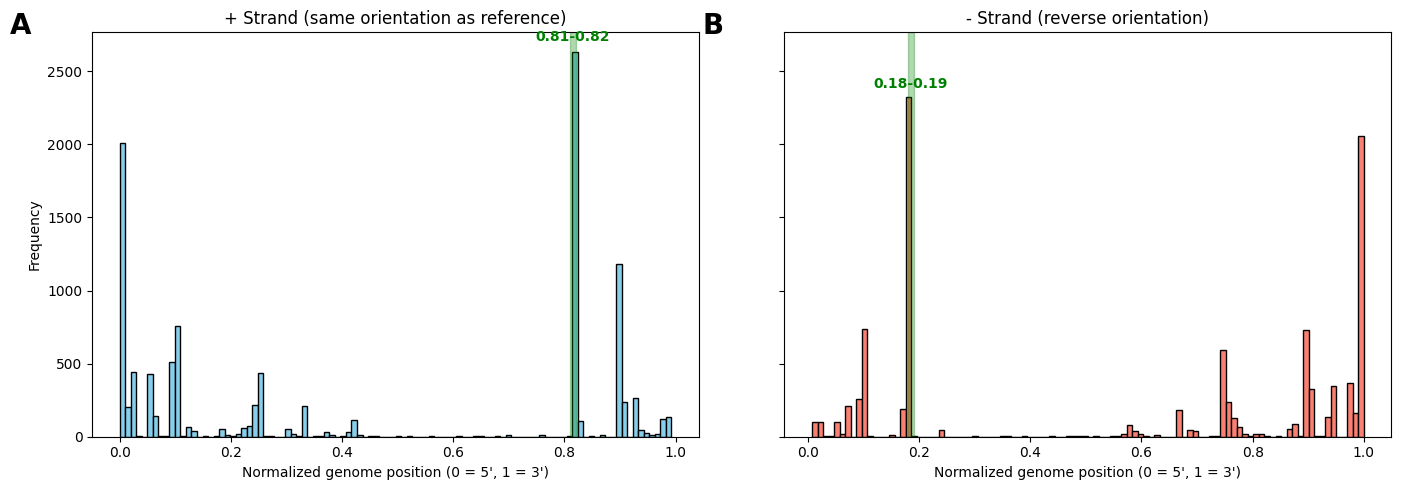

polyA illumina


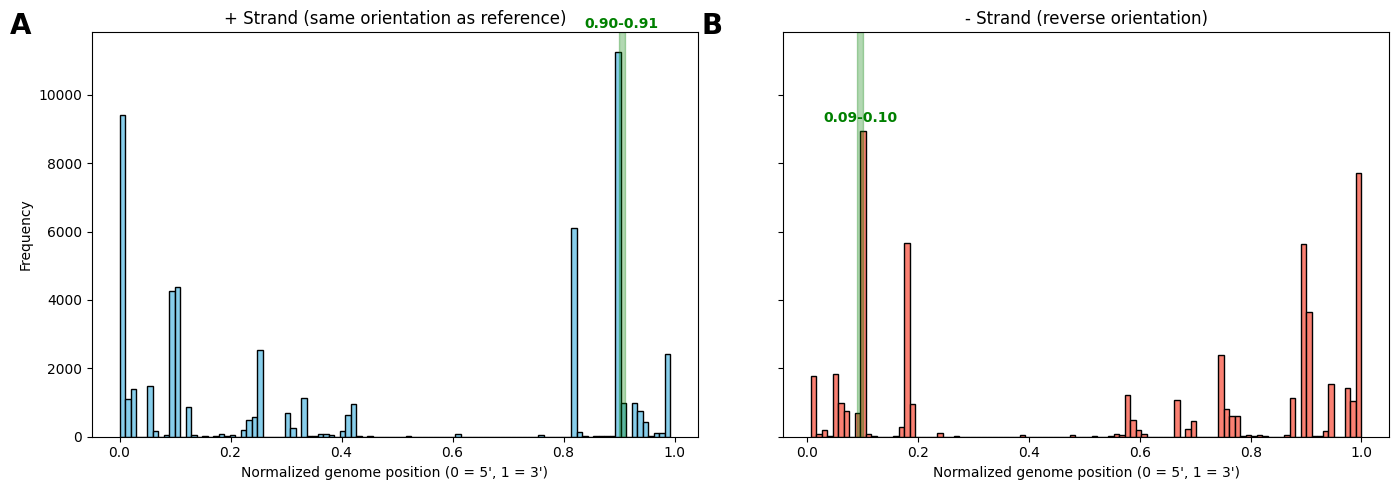

In [27]:

figs_path = "/gpfs/commons/home/mgarbulowski/016_proj_shm/data_polyA_comparison/illumina_data/figs"

print("control illumina")
out_fnam = figs_path + "/refseq_maping_coordinates_control_150m.png"
subdf1 = plot_and_extract_peak_bin(annotated_df1, out_fnam, bins=100)


print("polyA illumina")
out_fnam = figs_path + "/refseq_maping_coordinates_polyA_150m.png"
subdf2 = plot_and_extract_peak_bin(annotated_df2, out_fnam, bins=100)


In [28]:
subdf1plus = subdf1[subdf1["strand"] == "+"]
subdf2plus = subdf2[subdf2["strand"] == "+"]
print(subdf2plus)
subdf1mins = subdf1[subdf1["strand"] == "-"]
subdf2mins = subdf2[subdf2["strand"] == "-"]

vals_ctrl_pls = subdf1plus["Bfull_length"] - subdf1plus["start"]
vals_pap_pls = subdf2plus["Bfull_length"] - subdf2plus["start"]

vals_ctrl_mns = subdf1mins["Bfull_length"] - subdf1mins["start"]
vals_pap_mns = subdf2mins["Bfull_length"] - subdf2mins["start"]

                                               qseqid              sseqid  \
3         M00911:314:000000000-DV78T:1:1102:7744:4604  ref|NZ_LT821227.1|   
16       M00911:314:000000000-DV78T:1:1102:23768:4614  ref|NZ_LT821227.1|   
17       M00911:314:000000000-DV78T:1:1102:23250:4614  ref|NZ_LT821227.1|   
18       M00911:314:000000000-DV78T:1:1102:16612:4614  ref|NZ_LT821227.1|   
25        M00911:314:000000000-DV78T:1:1102:9220:4619  ref|NZ_LT821227.1|   
...                                               ...                 ...   
108298  M00911:314:000000000-DV78T:1:1101:20168:28345  ref|NZ_LT821227.1|   
108302  M00911:314:000000000-DV78T:1:1101:12946:28352  ref|NZ_LT821227.1|   
108319  M00911:314:000000000-DV78T:1:1101:15260:28376  ref|NZ_LT821227.1|   
108320  M00911:314:000000000-DV78T:1:1101:20085:28382  ref|NZ_LT821227.1|   
108323  M00911:314:000000000-DV78T:1:1101:13575:28385  ref|NZ_LT821227.1|   

          start      end strand  rel_start   rel_end         location  \
3 

NameError: name 'vst' is not defined

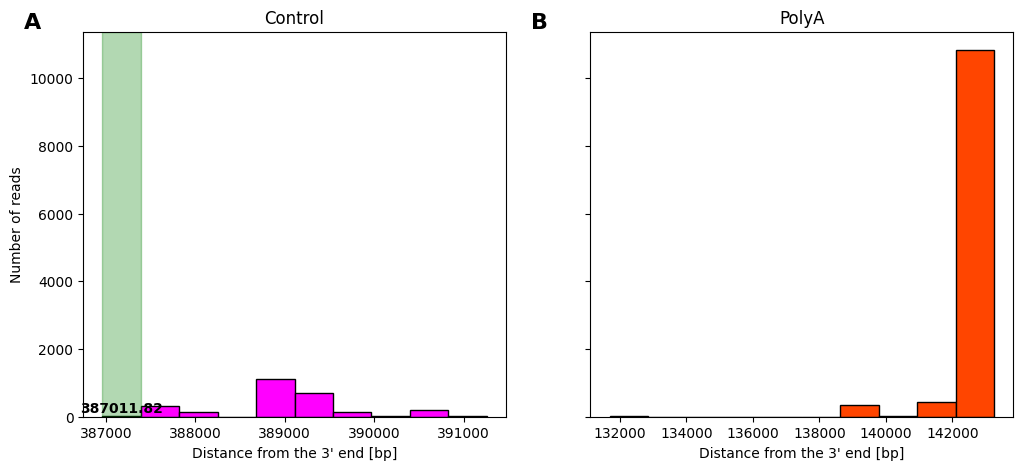

In [33]:
import matplotlib.pyplot as plt
import numpy as np

def plot_two_histograms(values1, values2, out_fnam, vstd=0.1, bins=5, color1='orange', color2='darkorange', title1='Histogram 1', title2='Histogram 2'):
    """
    Plot two histograms side by side with different colors, annotate the mean of the
    first bin near 0, highlight that bin, and label subplots with 'A' and 'B'.
    
    Parameters:
    - values1, values2: lists or arrays of numerical values
    - bins: number of bins for histograms
    - color1, color2: colors for the two histograms
    - title1, title2: subplot titles
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

    # First histogram
    counts1, bins1, _ = axes[0].hist(values1, bins=bins, color=color1, edgecolor='black')
    axes[0].set_title(title1)
    axes[0].set_xlabel("Distance from the 3' end [bp]")
    axes[0].set_ylabel("Number of reads")
    axes[0].text(-0.1, 1.05, "A", transform=axes[0].transAxes, fontsize=16, fontweight="bold", va="top", ha="right")

    # Leftmost bin near 0
    bin_idx1 = np.where(counts1 > 0)[0][0]
    bin_start1, bin_end1 = bins1[bin_idx1], bins1[bin_idx1 + 1]
    bin_values1 = [v for v in values1 if bin_start1 - vstd <= v < bin_end1 + vstd]
    mean_bin1 = np.mean(bin_values1)

    # Highlight bin
    axes[0].axvspan(bin_start1, bin_end1, color='green', alpha=0.3)

    # Annotate mean
    axes[0].text(
        (bin_start1 + bin_end1)/2,
        counts1[bin_idx1] + max(counts1)*0.02,
        f"{mean_bin1:.2f}",
        ha='center', va='bottom', color='black', fontsize=10, fontweight='bold'
    )

    # Second histogram
    counts2, bins2, _ = axes[1].hist(values2, bins=bins, color=color2, edgecolor='black')
    axes[1].set_title(title2)
    axes[1].set_xlabel("Distance from the 3' end [bp]")
    axes[1].text(-0.1, 1.05, "B", transform=axes[1].transAxes, fontsize=16, fontweight="bold", va="top", ha="right")

    # Leftmost bin near 0
    bin_idx2 = np.where(counts2 > 0)[0][0]
    bin_start2, bin_end2 = bins2[bin_idx2], bins2[bin_idx2 + 1]
    bin_values2 = [v for v in values2 if bin_start2 - vst <= v < bin_end2 + vstd]
    mean_bin2 = np.mean(bin_values2)

    # Highlight bin
    axes[1].axvspan(bin_start2, bin_end2, color='green', alpha=0.3)

    # Annotate mean
    axes[1].text(
        (bin_start2 + bin_end2)/2,
        counts2[bin_idx2] + max(counts2)*0.02,
        f"{mean_bin2:.2f}",
        ha='center', va='bottom', color='black', fontsize=10, fontweight='bold'
    )

    plt.tight_layout()
    plt.show()
    fig.savefig(out_fnam, dpi=300, bbox_inches="tight") 



# Example usage
values1 = vals_ctrl_pls
values2 = vals_pap_pls

out_fnam = figs_path + "/refseq_maping_coordinates_control_zoom_on_3prime_plus.png"
plot_two_histograms(values1, values2, out_fnam, vstd=0.1, bins=10, color1='fuchsia', color2='orangered',
                    title1='Control', title2='PolyA')




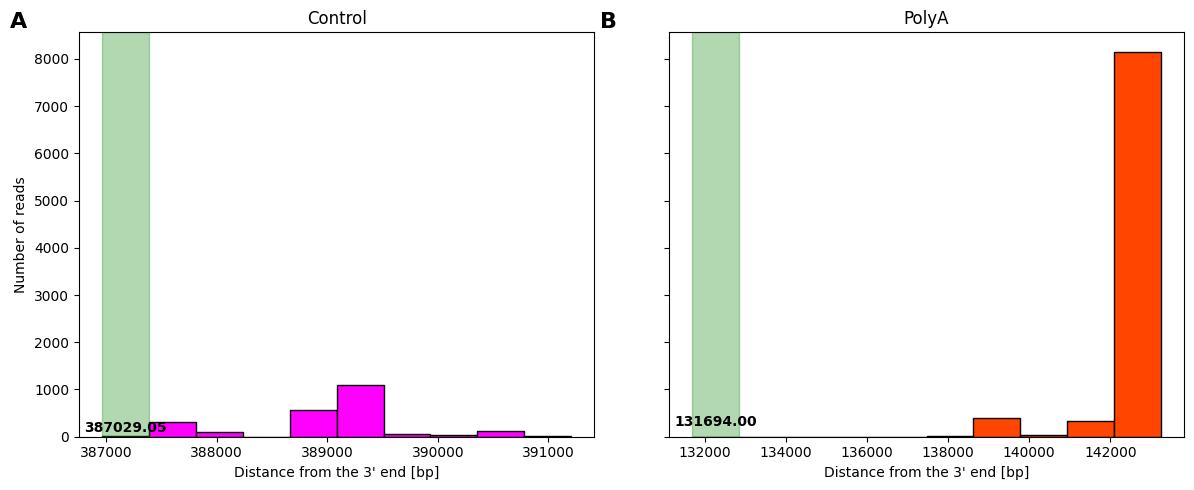

In [31]:
# Example usage
values3 = vals_ctrl_mns
values4 = vals_pap_mns

out_fnam = figs_path + "/refseq_maping_coordinates_control_zoom_on_3prime_minus.png"
plot_two_histograms(values3, values4, out_fnam, bins=10, color1='fuchsia', color2='orangered',
                    title1='Control', title2='PolyA')
